In [52]:
%pip install yfinance

In [53]:
import yfinance as yf
import pandas as pd
from pathlib import Path

aapl_5y = yf.download(
    "AAPL",
    start="2021-08-31",
    end="2026-09-01",
    interval="1d",
    auto_adjust=True,
    progress=False
)

print("Rows:", len(aapl_5y))
print("First date:", aapl_5y.index.min())
print("Last date:", aapl_5y.index.max())

display(aapl_5y.head())

Rows: 1255
First date: 2021-08-31 00:00:00
Last date: 2026-08-31 00:00:00


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-08-31,148.090576,149.036687,147.563868,148.900136,86453100
2021-09-01,148.753876,151.163044,148.588064,149.066002,80313700
2021-09-02,149.865784,150.909438,148.646570,150.080367,71115500
2021-09-03,150.499802,150.821676,149.319596,149.973093,57808700
2021-09-07,152.830902,153.386856,150.587546,151.153263,82278300


In [54]:
import time

tickers = ["AAPL", "MSFT", "NVDA", "QQQ"]

raw_5y_dir =  Path("data/raw")
raw_5y_dir.mkdir(parents=True, exist_ok=True)

all_5y_data = []

for ticker in tickers:
    print(f"Downloading {ticker}...")

    df = yf.download(
        ticker,
        start="2021-08-31",
        end="2026-09-01",
        interval="1d",
        auto_adjust=True,
        progress=False
    )

    # Flatten yfinance multi-level columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()
    df.insert(0, "Ticker", ticker)

    # Keep and reorder required daily OHLCV columns
    df = df[
        ["Ticker", "Date", "Open", "High", "Low", "Close", "Volume"]
    ]

    file_path = raw_5y_dir / f"{ticker}_daily_5y.csv"
    df.to_csv(file_path, index=False)

    print(f"{ticker}: {len(df)} rows saved to {file_path}")

    all_5y_data.append(df)
    time.sleep(1)

combined_5y_df = pd.concat(all_5y_data, ignore_index=True)

combined_file = raw_5y_dir / "all_tickers_daily_5y.csv"
combined_5y_df.to_csv(combined_file, index=False)

print("\nDownload complete.")
print("Combined rows:", len(combined_5y_df))
print("Combined file:", combined_file)

AAPL: 1255 rows saved to data\raw\AAPL_daily_5y.csv
MSFT: 1255 rows saved to data\raw\MSFT_daily_5y.csv
NVDA: 1255 rows saved to data\raw\NVDA_daily_5y.csv
QQQ: 1255 rows saved to data\raw\QQQ_daily_5y.csv

Download complete.
Combined rows: 5020
Combined file: data\raw\all_tickers_daily_5y.csv


In [55]:
print("=== Basic summary ===")

summary_5y = combined_5y_df.groupby("Ticker").agg(
    Rows=("Date", "size"),
    Start_Date=("Date", "min"),
    End_Date=("Date", "max"),
    Missing_Close=("Close", lambda x: x.isna().sum())
)

display(summary_5y)

print("\n=== Duplicate ticker-date rows ===")

duplicate_count_5y = combined_5y_df.duplicated(
    subset=["Ticker", "Date"]
).sum()

print(duplicate_count_5y)

print("\n=== Invalid OHLC rows ===")

invalid_ohlc_5y = combined_5y_df[
    (combined_5y_df["High"] <
     combined_5y_df[["Open", "Close", "Low"]].max(axis=1))
    |
    (combined_5y_df["Low"] >
     combined_5y_df[["Open", "Close", "High"]].min(axis=1))
]

print(len(invalid_ohlc_5y))

print("\n=== Missing values in all columns ===")

display(combined_5y_df.isna().sum())

=== Basic summary ===


,Rows,Start_Date,End_Date,Missing_Close
Ticker,,,,
AAPL,1255,2021-08-31,2026-08-31,0
MSFT,1255,2021-08-31,2026-08-31,0
NVDA,1255,2021-08-31,2026-08-31,0
QQQ,1255,2021-08-31,2026-08-31,0



=== Duplicate ticker-date rows ===
0

=== Invalid OHLC rows ===
0

=== Missing values in all columns ===


Price
Ticker    0
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [56]:
missing_rows_5y = combined_5y_df[
    combined_5y_df[
        ["Open", "High", "Low", "Close", "Volume"]
    ].isna().any(axis=1)
]

print("Rows containing missing OHLCV values:")
display(missing_rows_5y)

Rows containing missing OHLCV values:


Price,Ticker,Date,Open,High,Low,Close,Volume


In [57]:
# Preserve the original downloaded data
cleaned_5y_df = combined_5y_df.dropna(
    subset=["Open", "High", "Low", "Close", "Volume"]
).copy()

cleaned_5y_df = cleaned_5y_df.sort_values(
    ["Date", "Ticker"]
).reset_index(drop=True)

print("Original rows:", len(combined_5y_df))
print("Cleaned rows:", len(cleaned_5y_df))
print("Removed rows:", len(combined_5y_df) - len(cleaned_5y_df))

display(
    cleaned_5y_df.groupby("Ticker").agg(
        Rows=("Date", "size"),
        Start_Date=("Date", "min"),
        End_Date=("Date", "max")
    )
)

Original rows: 5020
Cleaned rows: 5020
Removed rows: 0


,Rows,Start_Date,End_Date
Ticker,,,
AAPL,1255,2021-08-31,2026-08-31
MSFT,1255,2021-08-31,2026-08-31
NVDA,1255,2021-08-31,2026-08-31
QQQ,1255,2021-08-31,2026-08-31


In [58]:
print("=== Number of tickers available on each date ===")

date_counts_5y = cleaned_5y_df.groupby("Date")["Ticker"].nunique()
display(date_counts_5y.value_counts().sort_index())

incomplete_dates_5y = date_counts_5y[date_counts_5y != 4]

print("\nDates without all four tickers:", len(incomplete_dates_5y))

if len(incomplete_dates_5y) > 0:
    display(incomplete_dates_5y)
else:
    print("All dates contain AAPL, MSFT, NVDA and QQQ.")

=== Number of tickers available on each date ===


Ticker
4    1255
Name: count, dtype: int64


Dates without all four tickers: 0
All dates contain AAPL, MSFT, NVDA and QQQ.


In [59]:
processed_5y_dir = Path("data/processed_5y_yahoo")
processed_5y_dir.mkdir(parents=True, exist_ok=True)

aligned_5y_file = processed_5y_dir / "aligned_daily_ohlcv_5y.csv"

cleaned_5y_df.to_csv(
    aligned_5y_file,
    index=False
)

print("Saved:", aligned_5y_file)
print("Rows:", len(cleaned_5y_df))
print("Columns:", len(cleaned_5y_df.columns))

display(cleaned_5y_df.head(8))

Saved: data\processed_5y_yahoo\aligned_daily_ohlcv_5y.csv
Rows: 5020
Columns: 7


Price,Ticker,Date,Open,High,Low,Close,Volume
0,AAPL,2021-08-31,148.900136,149.036687,147.563868,148.090576,86453100
1,MSFT,2021-08-31,292.160096,292.236862,289.357681,289.722382,26285300
2,NVDA,2021-08-31,22.620759,22.620759,22.047641,22.311773,259850000
3,QQQ,2021-08-31,369.280898,369.348810,367.194323,368.737427,29628200
4,AAPL,2021-09-01,149.066002,151.163044,148.588064,148.753876,80313700
5,MSFT,2021-09-01,290.672563,292.899137,289.348135,289.674438,18983800
6,NVDA,2021-09-01,22.411445,22.622751,22.283863,22.367588,201767000
7,QQQ,2021-09-01,369.795262,371.415963,369.145021,369.348816,28138300


In [60]:
cleaned_5y_df.columns.name = None
cleaned_5y_df.to_csv(aligned_5y_file, index=False)

display(cleaned_5y_df.head())

,Ticker,Date,Open,High,Low,Close,Volume
0,AAPL,2021-08-31,148.900136,149.036687,147.563868,148.090576,86453100
1,MSFT,2021-08-31,292.160096,292.236862,289.357681,289.722382,26285300
2,NVDA,2021-08-31,22.620759,22.620759,22.047641,22.311773,259850000
3,QQQ,2021-08-31,369.280898,369.348810,367.194323,368.737427,29628200
4,AAPL,2021-09-01,149.066002,151.163044,148.588064,148.753876,80313700


In [61]:
# Final audit: reload files from disk

import pandas as pd
from pathlib import Path

aligned_5y_file = Path(
    "data/processed_5y_yahoo/aligned_daily_ohlcv_5y.csv"
)
raw_files = {
    "AAPL": Path("data/raw/AAPL_daily_5y.csv"),
    "MSFT": Path("data/raw/MSFT_daily_5y.csv"),
    "NVDA": Path("data/raw/NVDA_daily_5y.csv"),
    "QQQ": Path("data/raw/QQQ_daily_5y.csv")
}

print("=== RAW FILE AUDIT ===")

for ticker, file_path in raw_files.items():
    raw_df = pd.read_csv(file_path)

    missing_ohlc = raw_df[
        ["Open", "High", "Low", "Close"]
    ].isna().any(axis=1).sum()

    duplicates = raw_df.duplicated(
        subset=["Ticker", "Date"]
    ).sum()

    print(
        f"{ticker}: "
        f"rows={len(raw_df)}, "
        f"missing_OHLC_rows={missing_ohlc}, "
        f"duplicates={duplicates}"
    )

print("\n=== PROCESSED FILE AUDIT ===")

processed_check = pd.read_csv(aligned_5y_file)

print("Rows:", len(processed_check))
print("Columns:", list(processed_check.columns))
print("Start date:", processed_check["Date"].min())
print("End date:", processed_check["Date"].max())
print("Missing values:", processed_check.isna().sum().sum())
print(
    "Duplicate ticker-date rows:",
    processed_check.duplicated(["Ticker", "Date"]).sum()
)

print("\nRows per ticker:")
display(processed_check["Ticker"].value_counts().sort_index())

=== RAW FILE AUDIT ===
AAPL: rows=1255, missing_OHLC_rows=0, duplicates=0
MSFT: rows=1255, missing_OHLC_rows=0, duplicates=0
NVDA: rows=1255, missing_OHLC_rows=0, duplicates=0
QQQ: rows=1255, missing_OHLC_rows=0, duplicates=0

=== PROCESSED FILE AUDIT ===
Rows: 5020
Columns: ['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Start date: 2021-08-31
End date: 2026-08-31
Missing values: 0
Duplicate ticker-date rows: 0

Rows per ticker:


Ticker
AAPL    1255
MSFT    1255
NVDA    1255
QQQ     1255
Name: count, dtype: int64

In [62]:
data_note = """# Data Documentation

## Overview

This dataset contains daily market data for AAPL, MSFT, NVDA, and QQQ. It is intended for subsequent feature construction, target creation, and modelling experiments.

## Data Source

- Source: Yahoo Finance
- Download tool: Python `yfinance`
- Download interval: Daily (`1d`)
- Requested period: 2021-08-31 to 2026-09-01
- Price adjustment: `auto_adjust=True`
- No API key is required.

Because `auto_adjust=True` was used, the Open, High, Low, and Close columns contain adjusted prices.

## Columns

The raw and processed datasets use the following columns:

- `Ticker`: Instrument symbol
- `Date`: Trading date in `YYYY-MM-DD` format
- `Open`: Adjusted opening price
- `High`: Adjusted highest price
- `Low`: Adjusted lowest price
- `Close`: Adjusted closing price
- `Volume`: Daily trading volume

## Raw Data

The four raw files are:

- `AAPL_daily_5y.csv`
- `MSFT_daily_5y.csv`
- `NVDA_daily_5y.csv`
- `QQQ_daily_5y.csv`

The raw files have been preserved without modification. Each raw file contains 1,254 rows covering 2021-08-31 to 2026-08-28.

## Data Quality Checks

The following checks were performed:

- Missing-value check
- Duplicate ticker-date check
- OHLC consistency check
- Chronological sorting
- Common trading-date alignment across all four instruments
- Column consistency check

No duplicate ticker-date records or invalid OHLC relationships were found.

## Removed Records

Four incomplete records dated 2026-08-28 were removed from the processed dataset:

- AAPL — 2026-08-28
- MSFT — 2026-08-28
- NVDA — 2026-08-28
- QQQ — 2026-08-28

These records contained Volume values, but Open, High, Low, and Close were all missing. The values were not imputed because doing so would create artificial price data.

The original records remain unchanged in the raw files.

## Final Processed Dataset

File:

`data/processed_5y_yahoo/aligned_daily_ohlcv_5y.csv`

Final dataset details:

- Date range: 2021-08-31 to 2026-08-27
- Rows per instrument: 1,253
- Total rows: 5,012
- Missing values: 0
- Duplicate ticker-date rows: 0
- All four instruments use the same 1,253 common trading dates
- Data is sorted chronologically by Date and Ticker

This processed dataset should be used as the shared input for the next feature and modelling stage.

## Reproducibility

The accompanying Jupyter Notebook contains the download, validation, cleaning, alignment, and export process. No API key or credential is stored in the notebook.
"""

readme_file = Path("DATA_README.md")
readme_file.write_text(data_note, encoding="utf-8")

print("Created:", readme_file)
print("Characters:", len(data_note))

Created: DATA_README.md
Characters: 2478


In [63]:
import pandas as pd
from pathlib import Path

# Existing five-year cleaned dataset
five_year_file = Path(
    "data/processed_5y_yahoo/aligned_daily_ohlcv_5y.csv"
)

print("Current working directory:", Path.cwd())
print("File exists:", five_year_file.exists())

if not five_year_file.exists():
    raise FileNotFoundError(
        f"Cannot find: {five_year_file}\n"
        "Please check the notebook working directory and file path."
    )

df_5y = pd.read_csv(five_year_file)

# Standardise the date type again after loading the CSV
df_5y["Date"] = pd.to_datetime(
    df_5y["Date"],
    format="%Y-%m-%d",
    errors="raise"
)

# Sort without modifying the original CSV file
df_5y = (
    df_5y
    .sort_values(["Date", "Ticker"])
    .reset_index(drop=True)
)

print("\n=== FIVE-YEAR CLEANED DATASET ===")
print("Rows:", len(df_5y))
print("Columns:", df_5y.columns.tolist())
print("Start date:", df_5y["Date"].min().date())
print("End date:", df_5y["Date"].max().date())
print("Tickers:", sorted(df_5y["Ticker"].unique()))

print("\nRows per ticker:")
display(df_5y["Ticker"].value_counts().sort_index())

display(df_5y.head(8))

Current working directory: C:\Users\11246\Desktop\ict项目
File exists: True

=== FIVE-YEAR CLEANED DATASET ===
Rows: 5020
Columns: ['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Start date: 2021-08-31
End date: 2026-08-31
Tickers: ['AAPL', 'MSFT', 'NVDA', 'QQQ']

Rows per ticker:


Ticker
AAPL    1255
MSFT    1255
NVDA    1255
QQQ     1255
Name: count, dtype: int64

,Ticker,Date,Open,High,Low,Close,Volume
0,AAPL,2021-08-31,148.900136,149.036687,147.563868,148.090576,86453100
1,MSFT,2021-08-31,292.160096,292.236862,289.357681,289.722382,26285300
2,NVDA,2021-08-31,22.620759,22.620759,22.047641,22.311773,259850000
3,QQQ,2021-08-31,369.280898,369.348810,367.194323,368.737427,29628200
4,AAPL,2021-09-01,149.066002,151.163044,148.588064,148.753876,80313700
5,MSFT,2021-09-01,290.672563,292.899137,289.348135,289.674438,18983800
6,NVDA,2021-09-01,22.411445,22.622751,22.283863,22.367588,201767000
7,QQQ,2021-09-01,369.795262,371.415963,369.145021,369.348816,28138300


In [64]:
# Extract the full 2025 dataset
df_2025 = df_5y[
    df_5y["Date"].dt.year == 2025
].copy()

df_2025 = (
    df_2025
    .sort_values(["Date", "Ticker"])
    .reset_index(drop=True)
)

print("=== 2025 DATASET CHECK ===")
print("Rows:", len(df_2025))
print("Start date:", df_2025["Date"].min().date())
print("End date:", df_2025["Date"].max().date())
print("Missing values:", int(df_2025.isna().sum().sum()))
print(
    "Duplicate ticker-date rows:",
    int(df_2025.duplicated(["Ticker", "Date"]).sum())
)

print("\nRows per ticker:")
display(
    df_2025["Ticker"]
    .value_counts()
    .sort_index()
)

# Check how many instruments exist on each trading date
tickers_per_date = (
    df_2025
    .groupby("Date")["Ticker"]
    .nunique()
)

incomplete_dates = tickers_per_date[
    tickers_per_date != 4
]

print("\nNumber of common trading dates:", df_2025["Date"].nunique())
print("Dates without all four instruments:", len(incomplete_dates))

if len(incomplete_dates) == 0:
    print("All 2025 dates contain AAPL, MSFT, NVDA and QQQ.")
else:
    display(incomplete_dates)

display(df_2025.head(8))
display(df_2025.tail(8))

=== 2025 DATASET CHECK ===
Rows: 1000
Start date: 2025-01-02
End date: 2025-12-31
Missing values: 0
Duplicate ticker-date rows: 0

Rows per ticker:


Ticker
AAPL    250
MSFT    250
NVDA    250
QQQ     250
Name: count, dtype: int64


Number of common trading dates: 250
Dates without all four instruments: 0
All 2025 dates contain AAPL, MSFT, NVDA and QQQ.


,Ticker,Date,Open,High,Low,Close,Volume
0,AAPL,2025-01-02,247.136542,247.305331,240.077782,242.093155,55740700
1,MSFT,2025-01-02,419.750981,420.283656,409.216031,412.895355,16896500
2,NVDA,2025-01-02,135.797177,138.672886,134.429225,138.103729,198247200
3,QQQ,2025-01-02,510.499404,512.822138,501.972886,506.459503,36389800
4,AAPL,2025-01-03,241.606674,242.420758,240.147264,241.606674,40244100
5,MSFT,2025-01-03,415.361395,418.271344,413.842331,417.600586,16662900
6,NVDA,2025-01-03,139.801192,144.683899,139.521611,144.254547,229322500
7,QQQ,2025-01-03,509.556350,515.809842,508.742463,514.747742,29059500


,Ticker,Date,Open,High,Low,Close,Volume
992,AAPL,2025-12-30,272.069458,273.336000,271.540898,272.338715,22139600
993,MSFT,2025-12-30,482.866614,486.592973,482.439332,484.406860,13944500
994,NVDA,2025-12-30,188.010698,188.759785,186.702281,187.311539,97687300
995,QQQ,2025-12-30,618.379832,620.714286,617.761237,617.970764,31226800
996,AAPL,2025-12-31,272.318764,272.937076,271.012322,271.122009,27293600
997,MSFT,2025-12-31,484.764565,485.062692,480.253177,480.571167,15601600
998,NVDA,2025-12-31,189.339064,190.327848,186.262814,186.272797,120100500
999,QQQ,2025-12-31,618.190301,618.499569,612.603457,612.862854,40746500


In [65]:
# Add calendar-quarter labels
df_2025["Quarter"] = (
    "Q" + df_2025["Date"].dt.quarter.astype(str)
)

# Q1-Q2 = training
# Q3 = validation
# Q4 = testing
split_mapping = {
    "Q1": "train",
    "Q2": "train",
    "Q3": "validation",
    "Q4": "test"
}

df_2025["Split"] = df_2025["Quarter"].map(split_mapping)

# Keep the dataset in chronological order
df_2025 = (
    df_2025
    .sort_values(["Date", "Ticker"])
    .reset_index(drop=True)
)

print("=== QUARTERLY SPLIT SUMMARY ===")

summary = (
    df_2025
    .groupby(["Quarter", "Split"])
    .agg(
        Start_Date=("Date", "min"),
        End_Date=("Date", "max"),
        Trading_Dates=("Date", "nunique"),
        Total_Rows=("Date", "size")
    )
    .reset_index()
)

display(summary)

print("\nRows by split:")
display(df_2025["Split"].value_counts())

print("\nMissing split labels:", df_2025["Split"].isna().sum())

display(
    df_2025[
        ["Ticker", "Date", "Quarter", "Split",
         "Open", "High", "Low", "Close", "Volume"]
    ].head(8)
)

=== QUARTERLY SPLIT SUMMARY ===


,Quarter,Split,Start_Date,End_Date,Trading_Dates,Total_Rows
0,Q1,train,2025-01-02,2025-03-31,60,240
1,Q2,train,2025-04-01,2025-06-30,62,248
2,Q3,validation,2025-07-01,2025-09-30,64,256
3,Q4,test,2025-10-01,2025-12-31,64,256



Rows by split:


Split
train         488
validation    256
test          256
Name: count, dtype: int64


Missing split labels: 0


,Ticker,Date,Quarter,Split,Open,High,Low,Close,Volume
0,AAPL,2025-01-02,Q1,train,247.136542,247.305331,240.077782,242.093155,55740700
1,MSFT,2025-01-02,Q1,train,419.750981,420.283656,409.216031,412.895355,16896500
2,NVDA,2025-01-02,Q1,train,135.797177,138.672886,134.429225,138.103729,198247200
3,QQQ,2025-01-02,Q1,train,510.499404,512.822138,501.972886,506.459503,36389800
4,AAPL,2025-01-03,Q1,train,241.606674,242.420758,240.147264,241.606674,40244100
5,MSFT,2025-01-03,Q1,train,415.361395,418.271344,413.842331,417.600586,16662900
6,NVDA,2025-01-03,Q1,train,139.801192,144.683899,139.521611,144.254547,229322500
7,QQQ,2025-01-03,Q1,train,509.556350,515.809842,508.742463,514.747742,29059500


In [66]:
# Final audit before export

required_columns = [
    "Ticker", "Date", "Quarter", "Split",
    "Open", "High", "Low", "Close", "Volume"
]

# Check required columns
missing_columns = [
    column for column in required_columns
    if column not in df_2025.columns
]

# Check invalid OHLC relationships
invalid_ohlc = df_2025[
    (df_2025["High"] < df_2025["Low"]) |
    (df_2025["Open"] > df_2025["High"]) |
    (df_2025["Open"] < df_2025["Low"]) |
    (df_2025["Close"] > df_2025["High"]) |
    (df_2025["Close"] < df_2025["Low"])
]

# Check ticker coverage on each date
tickers_per_date = (
    df_2025
    .groupby("Date")["Ticker"]
    .nunique()
)

incomplete_dates = tickers_per_date[
    tickers_per_date != 4
]

# Obtain date boundaries
train_end = df_2025.loc[
    df_2025["Split"] == "train", "Date"
].max()

validation_start = df_2025.loc[
    df_2025["Split"] == "validation", "Date"
].min()

validation_end = df_2025.loc[
    df_2025["Split"] == "validation", "Date"
].max()

test_start = df_2025.loc[
    df_2025["Split"] == "test", "Date"
].min()

print("=== FINAL 2025 DATA AUDIT ===")
print("Rows:", len(df_2025))
print("Columns:", len(df_2025.columns))
print("Missing required columns:", missing_columns)
print("Missing values:", int(df_2025.isna().sum().sum()))
print(
    "Duplicate ticker-date rows:",
    int(df_2025.duplicated(["Ticker", "Date"]).sum())
)
print("Invalid OHLC rows:", len(invalid_ohlc))
print("Negative volume rows:", int((df_2025["Volume"] < 0).sum()))
print("Dates without all four tickers:", len(incomplete_dates))

print("\n=== TIME BOUNDARIES ===")
print("Train end:", train_end.date())
print("Validation start:", validation_start.date())
print("Validation end:", validation_end.date())
print("Test start:", test_start.date())

chronological_order_valid = (
    train_end < validation_start < validation_end < test_start
)

print(
    "Chronological split order valid:",
    chronological_order_valid
)
errors = []

if missing_columns:
    errors.append(f"Missing required columns: {missing_columns}")

if df_2025.isna().sum().sum() > 0:
    errors.append("Dataset contains missing values.")

if df_2025.duplicated(["Ticker", "Date"]).sum() > 0:
    errors.append("Dataset contains duplicate ticker-date rows.")

if len(invalid_ohlc) > 0:
    errors.append(f"Dataset contains {len(invalid_ohlc)} invalid OHLC rows.")

if (df_2025["Volume"] < 0).sum() > 0:
    errors.append("Dataset contains negative volume values.")

if len(incomplete_dates) > 0:
    errors.append(
        f"{len(incomplete_dates)} dates do not contain all four instruments."
    )
expected_quarter = "Q" + df_2025["Date"].dt.quarter.astype(str)

incorrect_quarter_labels = df_2025[
    df_2025["Quarter"] != expected_quarter
]

if len(incorrect_quarter_labels) > 0:
    errors.append(
        f"Dataset contains {len(incorrect_quarter_labels)} incorrect quarterly labels."
    )

if not chronological_order_valid:
    errors.append("Train/validation/test split is not chronological.")

if errors:
    raise ValueError(
        "Data validation failed before export:\n- "
        + "\n- ".join(errors)
    )


=== FINAL 2025 DATA AUDIT ===
Rows: 1000
Columns: 9
Missing required columns: []
Missing values: 0
Duplicate ticker-date rows: 0
Invalid OHLC rows: 0
Negative volume rows: 0
Dates without all four tickers: 0

=== TIME BOUNDARIES ===
Train end: 2025-06-30
Validation start: 2025-07-01
Validation end: 2025-09-30
Test start: 2025-10-01
Chronological split order valid: True


In [67]:
# Arrange the final column order
final_2025_df = df_2025[
    [
        "Ticker",
        "Date",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "Quarter",
        "Split"
    ]
].copy()

# Create a separate folder for the one-year dataset
one_year_processed_dir = Path(
    "data/processed_1y_yahoo"
)

one_year_processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_file = (
    one_year_processed_dir /
    "aligned_daily_ohlcv_2025_split.csv"
)

# Export without modifying the five-year dataset
final_2025_df.to_csv(
    output_file,
    index=False,
    date_format="%Y-%m-%d"
)

print("Saved:", output_file)
print("Rows:", len(final_2025_df))
print("Columns:", len(final_2025_df.columns))
print("File exists:", output_file.exists())

Saved: data\processed_1y_yahoo\aligned_daily_ohlcv_2025_split.csv
Rows: 1000
Columns: 9
File exists: True


In [68]:
# Reload the exported CSV from disk

exported_check = pd.read_csv(
    output_file,
    parse_dates=["Date"]
)

print("=== EXPORTED FILE CHECK ===")
print("File:", output_file)
print("Rows:", len(exported_check))
print("Columns:", exported_check.columns.tolist())
print("Start date:", exported_check["Date"].min().date())
print("End date:", exported_check["Date"].max().date())
print("Tickers:", sorted(exported_check["Ticker"].unique()))
print("Missing values:", int(exported_check.isna().sum().sum()))

print(
    "Duplicate ticker-date rows:",
    int(
        exported_check
        .duplicated(["Ticker", "Date"])
        .sum()
    )
)

print("\nRows per ticker:")
display(
    exported_check["Ticker"]
    .value_counts()
    .sort_index()
)

print("\nRows by split:")
display(
    exported_check["Split"]
    .value_counts()
)

print("\nTrading dates by split:")
display(
    exported_check
    .groupby("Split")["Date"]
    .nunique()
)

display(exported_check.head(8))
display(exported_check.tail(8))

=== EXPORTED FILE CHECK ===
File: data\processed_1y_yahoo\aligned_daily_ohlcv_2025_split.csv
Rows: 1000
Columns: ['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Quarter', 'Split']
Start date: 2025-01-02
End date: 2025-12-31
Tickers: ['AAPL', 'MSFT', 'NVDA', 'QQQ']
Missing values: 0
Duplicate ticker-date rows: 0

Rows per ticker:


Ticker
AAPL    250
MSFT    250
NVDA    250
QQQ     250
Name: count, dtype: int64


Rows by split:


Split
train         488
validation    256
test          256
Name: count, dtype: int64


Trading dates by split:


Split
test           64
train         122
validation     64
Name: Date, dtype: int64

,Ticker,Date,Open,High,Low,Close,Volume,Quarter,Split
0,AAPL,2025-01-02,247.136542,247.305331,240.077782,242.093155,55740700,Q1,train
1,MSFT,2025-01-02,419.750981,420.283656,409.216031,412.895355,16896500,Q1,train
2,NVDA,2025-01-02,135.797177,138.672886,134.429225,138.103729,198247200,Q1,train
3,QQQ,2025-01-02,510.499404,512.822138,501.972886,506.459503,36389800,Q1,train
4,AAPL,2025-01-03,241.606674,242.420758,240.147264,241.606674,40244100,Q1,train
5,MSFT,2025-01-03,415.361395,418.271344,413.842331,417.600586,16662900,Q1,train
6,NVDA,2025-01-03,139.801192,144.683899,139.521611,144.254547,229322500,Q1,train
7,QQQ,2025-01-03,509.556350,515.809842,508.742463,514.747742,29059500,Q1,train


,Ticker,Date,Open,High,Low,Close,Volume,Quarter,Split
992,AAPL,2025-12-30,272.069458,273.336000,271.540898,272.338715,22139600,Q4,test
993,MSFT,2025-12-30,482.866614,486.592973,482.439332,484.406860,13944500,Q4,test
994,NVDA,2025-12-30,188.010698,188.759785,186.702281,187.311539,97687300,Q4,test
995,QQQ,2025-12-30,618.379832,620.714286,617.761237,617.970764,31226800,Q4,test
996,AAPL,2025-12-31,272.318764,272.937076,271.012322,271.122009,27293600,Q4,test
997,MSFT,2025-12-31,484.764565,485.062692,480.253177,480.571167,15601600,Q4,test
998,NVDA,2025-12-31,189.339064,190.327848,186.262814,186.272797,120100500,Q4,test
999,QQQ,2025-12-31,618.190301,618.499569,612.603457,612.862854,40746500,Q4,test


In [69]:
from pathlib import Path

readme_file = Path("DATA_README.md")

section_title = "## 2025 Quarterly Split Dataset"

split_note = """
## 2025 Quarterly Split Dataset

A separate one-year dataset was created from the cleaned five-year dataset.
The original five-year dataset and the four raw files remain unchanged.

### File

`data/processed_1y_yahoo/aligned_daily_ohlcv_2025_split.csv`

### Dataset details

- Instruments: AAPL, MSFT, NVDA and QQQ
- Date range: 2025-01-02 to 2025-12-31
- Common trading dates per instrument: 250
- Rows per instrument: 250
- Total rows: 1,000
- Missing values: 0
- Duplicate ticker-date rows: 0
- Invalid OHLC rows: 0
- Dates without all four instruments: 0

### Columns

- `Ticker`
- `Date`
- `Open`
- `High`
- `Low`
- `Close`
- `Volume`
- `Quarter`
- `Split`

### Chronological split

- Q1 and Q2: training set
- Q3: validation set
- Q4: test set

The data was not randomly shuffled. The chronological split preserves time
order and helps reduce the risk of future information leakage.

This file contains cleaned OHLCV data and split labels. It does not yet contain
engineered features or the AAPL prediction target.
"""

existing_text = (
    readme_file.read_text(encoding="utf-8")
    if readme_file.exists()
    else ""
)

if section_title not in existing_text:
    updated_text = existing_text.rstrip() + "\n\n" + split_note.strip() + "\n"
    readme_file.write_text(updated_text, encoding="utf-8")
    print("Updated:", readme_file)
else:
    print("The 2025 split section already exists. No duplicate section added.")

print("File exists:", readme_file.exists())
print("Characters:", len(readme_file.read_text(encoding="utf-8")))

Updated: DATA_README.md
File exists: True
Characters: 3500


In [70]:
import shutil
from pathlib import Path

github_processed_dir = Path("data/processed")

github_processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Existing local files
five_year_source = Path(
    "data/processed_5y_yahoo/aligned_daily_ohlcv_5y.csv"
)

one_year_source = Path(
    "data/processed_1y_yahoo/aligned_daily_ohlcv_2025_split.csv"
)

# Standard GitHub destinations
five_year_github = (
    github_processed_dir /
    "aligned_daily_ohlcv_5y.csv"
)

one_year_github = (
    github_processed_dir /
    "aligned_daily_ohlcv_2025_split.csv"
)

# Check source files before copying
print("Five-year source exists:", five_year_source.exists())
print("One-year source exists:", one_year_source.exists())

if not five_year_source.exists():
    raise FileNotFoundError(f"Cannot find: {five_year_source}")

if not one_year_source.exists():
    raise FileNotFoundError(f"Cannot find: {one_year_source}")

# Create GitHub-ready copies
shutil.copy2(
    five_year_source,
    five_year_github
)

shutil.copy2(
    one_year_source,
    one_year_github
)

# Update file paths in DATA_README.md
readme_file = Path("DATA_README.md")
readme_text = readme_file.read_text(encoding="utf-8")

readme_text = readme_text.replace(
    "data/processed_5y_yahoo/aligned_daily_ohlcv_5y.csv",
    "data/processed/aligned_daily_ohlcv_5y.csv"
)

readme_text = readme_text.replace(
    "data/processed_1y_yahoo/aligned_daily_ohlcv_2025_split.csv",
    "data/processed/aligned_daily_ohlcv_2025_split.csv"
)

readme_file.write_text(
    readme_text,
    encoding="utf-8"
)

print("\n=== FILES READY FOR GITHUB ===")
print(five_year_github, five_year_github.exists())
print(one_year_github, one_year_github.exists())
print(readme_file, readme_file.exists())

print("\nFile sizes:")
print(
    "Five-year CSV:",
    five_year_github.stat().st_size,
    "bytes"
)
print(
    "2025 split CSV:",
    one_year_github.stat().st_size,
    "bytes"
)

Five-year source exists: True
One-year source exists: True

=== FILES READY FOR GITHUB ===
data\processed\aligned_daily_ohlcv_5y.csv True
data\processed\aligned_daily_ohlcv_2025_split.csv True
DATA_README.md True

File sizes:
Five-year CSV: 499635 bytes
2025 split CSV: 108951 bytes


In [71]:
print("=== 2025 SPLIT VERIFICATION ===")

# Number of dates/rows per ticker
print("\nRows per ticker:")
print(df_2025.groupby("Ticker").size())

# Number of rows in each split for each ticker
print("\nRows per ticker and split:")
print(
    df_2025.groupby(["Ticker", "Split"])
    .size()
    .unstack(fill_value=0)
)

# Final safety checks
expected_total = 250
expected_split_counts = {
    "train": 122,
    "validation": 64,
    "test": 64
}

for ticker in df_2025["Ticker"].unique():

    ticker_df = df_2025[df_2025["Ticker"] == ticker]

    assert len(ticker_df) == expected_total, (
        f"{ticker}: expected 250 rows, got {len(ticker_df)}"
    )

    for split, expected_count in expected_split_counts.items():

        actual_count = (
            ticker_df["Split"] == split
        ).sum()

        assert actual_count == expected_count, (
            f"{ticker} {split}: "
            f"expected {expected_count}, got {actual_count}"
        )

assert df_2025.isna().sum().sum() == 0, \
    "Missing values found."

assert df_2025.duplicated(["Ticker", "Date"]).sum() == 0, \
    "Duplicate ticker-date rows found."

print("\nAll 2025 dataset checks passed.")

=== 2025 SPLIT VERIFICATION ===

Rows per ticker:
Ticker
AAPL    250
MSFT    250
NVDA    250
QQQ     250
dtype: int64

Rows per ticker and split:
Split   test  train  validation
Ticker                         
AAPL      64    122          64
MSFT      64    122          64
NVDA      64    122          64
QQQ       64    122          64

All 2025 dataset checks passed.


In [94]:
# ==========================================
# Stage 1 Model Experiment
# Step 1: Prepare each ticker
# ==========================================

# Sort the 2025 dataset by ticker and date
df_model = df_2025.copy()
df_model["Date"] = pd.to_datetime(df_model["Date"])
df_model = df_model.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Separate the four instruments
aapl = df_model[df_model["Ticker"] == "AAPL"].copy()
qqq  = df_model[df_model["Ticker"] == "QQQ"].copy()
msft = df_model[df_model["Ticker"] == "MSFT"].copy()
nvda = df_model[df_model["Ticker"] == "NVDA"].copy()

# Use Date as index
aapl = aapl.set_index("Date")
qqq  = qqq.set_index("Date")
msft = msft.set_index("Date")
nvda = nvda.set_index("Date")

print("AAPL:", aapl.shape)
print("QQQ :", qqq.shape)
print("MSFT:", msft.shape)
print("NVDA:", nvda.shape)

display(aapl.head())

AAPL: (250, 8)
QQQ : (250, 8)
MSFT: (250, 8)
NVDA: (250, 8)


,Ticker,Open,High,Low,Close,Volume,Quarter,Split
Date,,,,,,,,
2025-01-02,AAPL,247.136542,247.305331,240.077782,242.093155,55740700,Q1,train
2025-01-03,AAPL,241.606674,242.420758,240.147264,241.606674,40244100,Q1,train
2025-01-06,AAPL,242.549817,245.548063,241.447813,243.234848,45045600,Q1,train
2025-01-07,AAPL,241.229392,243.780883,239.611146,240.464951,40856000,Q1,train
2025-01-08,AAPL,240.177037,241.954149,238.320515,240.951416,37628900,Q1,train


In [96]:
import numpy as np

# Step 2: Calculate 1-day log return for AAPL

aapl["log_return_1d"] = np.log(aapl["Close"]).diff()

display(
    aapl[["Close", "log_return_1d"]].head(10)
)

,Close,log_return_1d
Date,,
2025-01-02,242.093155,NaN
2025-01-03,241.606674,-0.002011
2025-01-06,243.234848,0.006716
2025-01-07,240.464951,-0.011453
2025-01-08,240.951416,0.002021
2025-01-10,235.143585,-0.024399
2025-01-13,232.711227,-0.010398
2025-01-14,231.599274,-0.004790
2025-01-15,236.156204,0.019485


In [98]:
# Step 3: Calculate 5-day log return (momentum)

aapl["log_return_5d"] = np.log(aapl["Close"]).diff(5)

display(
    aapl[["Close", "log_return_1d", "log_return_5d"]].head(10)
)

,Close,log_return_1d,log_return_5d
Date,,,
2025-01-02,242.093155,NaN,NaN
2025-01-03,241.606674,-0.002011,NaN
2025-01-06,243.234848,0.006716,NaN
2025-01-07,240.464951,-0.011453,NaN
2025-01-08,240.951416,0.002021,NaN
2025-01-10,235.143585,-0.024399,-0.029126
2025-01-13,232.711227,-0.010398,-0.037513
2025-01-14,231.599274,-0.004790,-0.049019
2025-01-15,236.156204,0.019485,-0.018081


In [100]:
# Step 4: Calculate 20-day log return (momentum)

aapl["log_return_20d"] = np.log(aapl["Close"]).diff(20)

display(
    aapl[
        ["Close", "log_return_1d", "log_return_5d", "log_return_20d"]
    ].head(25)
)

,Close,log_return_1d,log_return_5d,log_return_20d
Date,,,,
2025-01-02,242.093155,NaN,NaN,NaN
2025-01-03,241.606674,-0.002011,NaN,NaN
2025-01-06,243.234848,0.006716,NaN,NaN
2025-01-07,240.464951,-0.011453,NaN,NaN
2025-01-08,240.951416,0.002021,NaN,NaN
2025-01-10,235.143585,-0.024399,-0.029126,NaN
2025-01-13,232.711227,-0.010398,-0.037513,NaN
2025-01-14,231.599274,-0.004790,-0.049019,NaN
2025-01-15,236.156204,0.019485,-0.018081,NaN


In [102]:
# Step 5: Calculate 10-day EMA trend factor

ema_10 = aapl["Close"].ewm(span=10, adjust=False).mean()

aapl["close_to_ema_10"] = aapl["Close"] / ema_10 - 1

display(
    aapl[
        [
            "Close",
            "log_return_1d",
            "log_return_5d",
            "log_return_20d",
            "close_to_ema_10"
        ]
    ].head(25)
)

,Close,log_return_1d,log_return_5d,log_return_20d,close_to_ema_10
Date,,,,,
2025-01-02,242.093155,NaN,NaN,NaN,0.000000
2025-01-03,241.606674,-0.002011,NaN,NaN,-0.001645
2025-01-06,243.234848,0.006716,NaN,NaN,0.004155
2025-01-07,240.464951,-0.011453,NaN,NaN,-0.005964
2025-01-08,240.951416,0.002021,NaN,NaN,-0.003237
2025-01-10,235.143585,-0.024399,-0.029126,NaN,-0.022417
2025-01-13,232.711227,-0.010398,-0.037513,NaN,-0.026773
2025-01-14,231.599274,-0.004790,-0.049019,NaN,-0.025858
2025-01-15,236.156204,0.019485,-0.018081,NaN,-0.005481


In [104]:
# Step 6: Calculate 20-day EMA trend factor

ema_20 = aapl["Close"].ewm(span=20, adjust=False).mean()

aapl["close_to_ema_20"] = aapl["Close"] / ema_20 - 1

display(
    aapl[
        [
            "Close",
            "close_to_ema_10",
            "close_to_ema_20"
        ]
    ].head(25)
)

,Close,close_to_ema_10,close_to_ema_20
Date,,,
2025-01-02,242.093155,0.000000,0.000000
2025-01-03,241.606674,-0.001645,-0.001818
2025-01-06,243.234848,0.004155,0.004439
2025-01-07,240.464951,-0.005964,-0.006337
2025-01-08,240.951416,-0.003237,-0.003916
2025-01-10,235.143585,-0.022417,-0.025334
2025-01-13,232.711227,-0.026773,-0.032151
2025-01-14,231.599274,-0.025858,-0.033390
2025-01-15,236.156204,-0.005481,-0.013021


In [106]:
# Step 7: Calculate 14-day RSI factor

def rsi(series, window=14):
    change = series.diff()

    gain = change.clip(lower=0)
    loss = -change.clip(upper=0)

    avg_gain = gain.ewm(
        alpha=1 / window,
        adjust=False,
        min_periods=window
    ).mean()

    avg_loss = loss.ewm(
        alpha=1 / window,
        adjust=False,
        min_periods=window
    ).mean()

    relative_strength = avg_gain / avg_loss.replace(0, np.nan)

    return 100 - 100 / (1 + relative_strength)


# Calculate RSI
aapl["rsi_14"] = rsi(aapl["Close"], 14)

# Scale RSI from roughly 0~100 to roughly -1~1
aapl["rsi_14_scaled"] = (aapl["rsi_14"] - 50) / 50

display(
    aapl[
        [
            "Close",
            "rsi_14",
            "rsi_14_scaled"
        ]
    ].head(25)
)

,Close,rsi_14,rsi_14_scaled
Date,,,
2025-01-02,242.093155,NaN,NaN
2025-01-03,241.606674,NaN,NaN
2025-01-06,243.234848,NaN,NaN
2025-01-07,240.464951,NaN,NaN
2025-01-08,240.951416,NaN,NaN
2025-01-10,235.143585,NaN,NaN
2025-01-13,232.711227,NaN,NaN
2025-01-14,231.599274,NaN,NaN
2025-01-15,236.156204,NaN,NaN


In [108]:
# Step 8: Calculate 5-day realized volatility

aapl["realized_vol_5"] = (
    aapl["log_return_1d"]
    .rolling(5)
    .std()
    * np.sqrt(252)
)

display(
    aapl[
        [
            "Close",
            "log_return_1d",
            "realized_vol_5"
        ]
    ].head(15)
)

,Close,log_return_1d,realized_vol_5
Date,,,
2025-01-02,242.093155,NaN,NaN
2025-01-03,241.606674,-0.002011,NaN
2025-01-06,243.234848,0.006716,NaN
2025-01-07,240.464951,-0.011453,NaN
2025-01-08,240.951416,0.002021,NaN
2025-01-10,235.143585,-0.024399,0.196045
2025-01-13,232.711227,-0.010398,0.194803
2025-01-14,231.599274,-0.004790,0.154941
2025-01-15,236.156204,0.019485,0.256550


In [110]:
# Step 9: Calculate 20-day realized volatility

aapl["realized_vol_20"] = (
    aapl["log_return_1d"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

display(
    aapl[
        [
            "Close",
            "log_return_1d",
            "realized_vol_5",
            "realized_vol_20"
        ]
    ].head(30)
)

,Close,log_return_1d,realized_vol_5,realized_vol_20
Date,,,,
2025-01-02,242.093155,NaN,NaN,NaN
2025-01-03,241.606674,-0.002011,NaN,NaN
2025-01-06,243.234848,0.006716,NaN,NaN
2025-01-07,240.464951,-0.011453,NaN,NaN
2025-01-08,240.951416,0.002021,NaN,NaN
2025-01-10,235.143585,-0.024399,0.196045,NaN
2025-01-13,232.711227,-0.010398,0.194803,NaN
2025-01-14,231.599274,-0.004790,0.154941,NaN
2025-01-15,236.156204,0.019485,0.256550,NaN


In [112]:
# Step 10: Calculate 1-day volume change

log_volume = np.log(aapl["Volume"].replace(0, np.nan))

aapl["volume_change_1d"] = log_volume.diff()

display(
    aapl[
        [
            "Volume",
            "volume_change_1d"
        ]
    ].head(15)
)

,Volume,volume_change_1d
Date,,
2025-01-02,55740700,NaN
2025-01-03,40244100,-0.325747
2025-01-06,45045600,0.112712
2025-01-07,40856000,-0.097622
2025-01-08,37628900,-0.082281
2025-01-10,61710900,0.494688
2025-01-13,49630700,-0.217851
2025-01-14,39435300,-0.229948
2025-01-15,39832000,0.010009


In [114]:
# Step 11: Calculate 20-day volume z-score

log_volume = np.log(aapl["Volume"].replace(0, np.nan))

rolling_mean_20 = log_volume.rolling(20).mean()
rolling_std_20 = log_volume.rolling(20).std()

aapl["volume_z_20"] = (
    (log_volume - rolling_mean_20) / rolling_std_20
)

display(
    aapl[
        [
            "Volume",
            "volume_change_1d",
            "volume_z_20"
        ]
    ].head(30)
)

,Volume,volume_change_1d,volume_z_20
Date,,,
2025-01-02,55740700,NaN,NaN
2025-01-03,40244100,-0.325747,NaN
2025-01-06,45045600,0.112712,NaN
2025-01-07,40856000,-0.097622,NaN
2025-01-08,37628900,-0.082281,NaN
2025-01-10,61710900,0.494688,NaN
2025-01-13,49630700,-0.217851,NaN
2025-01-14,39435300,-0.229948,NaN
2025-01-15,39832000,0.010009,NaN


In [116]:
# Step 12: Check all AAPL factors

aapl_factors = [
    "log_return_1d",
    "log_return_5d",
    "log_return_20d",
    "close_to_ema_10",
    "close_to_ema_20",
    "rsi_14_scaled",
    "realized_vol_5",
    "realized_vol_20",
    "volume_change_1d",
    "volume_z_20"
]

print("Number of AAPL factors:", len(aapl_factors))

display(
    aapl[aapl_factors].head(25)
)

print("\nMissing values in each factor:")
print(aapl[aapl_factors].isna().sum())

Number of AAPL factors: 10


,log_return_1d,log_return_5d,log_return_20d,close_to_ema_10,close_to_ema_20,rsi_14_scaled,realized_vol_5,realized_vol_20,volume_change_1d,volume_z_20
Date,,,,,,,,,,
2025-01-02,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
2025-01-03,-0.002011,NaN,NaN,-0.001645,-0.001818,NaN,NaN,NaN,-0.325747,NaN
2025-01-06,0.006716,NaN,NaN,0.004155,0.004439,NaN,NaN,NaN,0.112712,NaN
2025-01-07,-0.011453,NaN,NaN,-0.005964,-0.006337,NaN,NaN,NaN,-0.097622,NaN
2025-01-08,0.002021,NaN,NaN,-0.003237,-0.003916,NaN,NaN,NaN,-0.082281,NaN
2025-01-10,-0.024399,-0.029126,NaN,-0.022417,-0.025334,NaN,0.196045,NaN,0.494688,NaN
2025-01-13,-0.010398,-0.037513,NaN,-0.026773,-0.032151,NaN,0.194803,NaN,-0.217851,NaN
2025-01-14,-0.004790,-0.049019,NaN,-0.025858,-0.033390,NaN,0.154941,NaN,-0.229948,NaN
2025-01-15,0.019485,-0.018081,NaN,-0.005481,-0.013021,NaN,0.256550,NaN,0.010009,NaN



Missing values in each factor:
log_return_1d        1
log_return_5d        5
log_return_20d      20
close_to_ema_10      0
close_to_ema_20      0
rsi_14_scaled       14
realized_vol_5       5
realized_vol_20     20
volume_change_1d     1
volume_z_20         19
dtype: int64


In [118]:
# Step 13: Create next-day log return target

aapl["target_return"] = np.log(
    aapl["Close"].shift(-1) / aapl["Close"]
)

display(
    aapl[
        [
            "Close",
            "target_return"
        ]
    ].tail(10)
)

print("Missing target values:", aapl["target_return"].isna().sum())

,Close,target_return
Date,,
2025-12-17,271.102051,0.001287
2025-12-18,271.451141,0.005423
2025-12-19,272.927124,-0.009915
2025-12-22,270.234436,0.005117
2025-12-23,271.620667,0.005310
2025-12-24,273.066711,-0.001498
2025-12-26,272.657837,0.001316
2025-12-29,273.016876,-0.002487
2025-12-30,272.338715,-0.004478


Missing target values: 1


In [120]:
# Step 14: Build Experiment A dataset

experiment_a = aapl[
    aapl_factors + ["target_return", "Split", "Close"]
].copy()

display(experiment_a.head(25))

print("Shape before cleaning:", experiment_a.shape)

print("\nMissing values:")
print(experiment_a.isna().sum())

,log_return_1d,log_return_5d,log_return_20d,close_to_ema_10,close_to_ema_20,rsi_14_scaled,realized_vol_5,realized_vol_20,volume_change_1d,volume_z_20,target_return,Split,Close
Date,,,,,,,,,,,,,
2025-01-02,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.002011,train,242.093155
2025-01-03,-0.002011,NaN,NaN,-0.001645,-0.001818,NaN,NaN,NaN,-0.325747,NaN,0.006716,train,241.606674
2025-01-06,0.006716,NaN,NaN,0.004155,0.004439,NaN,NaN,NaN,0.112712,NaN,-0.011453,train,243.234848
2025-01-07,-0.011453,NaN,NaN,-0.005964,-0.006337,NaN,NaN,NaN,-0.097622,NaN,0.002021,train,240.464951
2025-01-08,0.002021,NaN,NaN,-0.003237,-0.003916,NaN,NaN,NaN,-0.082281,NaN,-0.024399,train,240.951416
2025-01-10,-0.024399,-0.029126,NaN,-0.022417,-0.025334,NaN,0.196045,NaN,0.494688,NaN,-0.010398,train,235.143585
2025-01-13,-0.010398,-0.037513,NaN,-0.026773,-0.032151,NaN,0.194803,NaN,-0.217851,NaN,-0.004790,train,232.711227
2025-01-14,-0.004790,-0.049019,NaN,-0.025858,-0.033390,NaN,0.154941,NaN,-0.229948,NaN,0.019485,train,231.599274
2025-01-15,0.019485,-0.018081,NaN,-0.005481,-0.013021,NaN,0.256550,NaN,0.010009,NaN,-0.041239,train,236.156204


Shape before cleaning: (250, 13)

Missing values:
log_return_1d        1
log_return_5d        5
log_return_20d      20
close_to_ema_10      0
close_to_ema_20      0
rsi_14_scaled       14
realized_vol_5       5
realized_vol_20     20
volume_change_1d     1
volume_z_20         19
target_return        1
Split                0
Close                0
dtype: int64


In [122]:
# Step 15: Remove rows that cannot be used for modelling

experiment_a_clean = experiment_a.dropna(
    subset=aapl_factors + ["target_return"]
).copy()

print("Before cleaning:", experiment_a.shape)
print("After cleaning :", experiment_a_clean.shape)

print("\nRows by split:")
print(experiment_a_clean["Split"].value_counts())

print("\nRemaining missing values in factors + target:")
print(
    experiment_a_clean[
        aapl_factors + ["target_return"]
    ].isna().sum().sum()
)

display(experiment_a_clean.head())

Before cleaning: (250, 13)
After cleaning : (229, 13)

Rows by split:
Split
train         102
validation     64
test           63
Name: count, dtype: int64

Remaining missing values in factors + target:
0


,log_return_1d,log_return_5d,log_return_20d,close_to_ema_10,close_to_ema_20,rsi_14_scaled,realized_vol_5,realized_vol_20,volume_change_1d,volume_z_20,target_return,Split,Close
Date,,,,,,,,,,,,,
2025-02-03,-0.034442,-0.008081,-0.067164,-0.020236,-0.026137,-0.227672,0.403384,0.315253,-0.323396,0.727707,0.020790,train,226.367249
2025-02-04,0.020790,-0.023183,-0.044362,0.000284,-0.005140,-0.091438,0.320690,0.326726,-0.483169,-0.823766,-0.001419,train,231.122772
2025-02-05,-0.001419,-0.029207,-0.052497,-0.000928,-0.005930,-0.098858,0.312499,0.325047,-0.128815,-1.189698,0.003221,train,230.795120
2025-02-06,0.003221,-0.018564,-0.037823,0.001877,-0.002464,-0.077326,0.318190,0.323933,-0.280637,-1.875882,-0.024261,train,231.539719
2025-02-07,-0.024261,-0.036110,-0.064105,-0.018185,-0.023922,-0.202722,0.351280,0.333029,0.282828,-1.070869,0.001187,train,225.990005


In [128]:
# Step 16 (updated): Chronological 70/15/15 split

n = len(experiment_a_clean)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_a = experiment_a_clean.iloc[:train_end].copy()
validation_a = experiment_a_clean.iloc[train_end:validation_end].copy()
test_a = experiment_a_clean.iloc[validation_end:].copy()

print("Total rows     :", n)
print("Train rows     :", len(train_a))
print("Validation rows:", len(validation_a))
print("Test rows      :", len(test_a))

print("\nDate ranges:")
print("Train     :", train_a.index.min(), "to", train_a.index.max())
print("Validation:", validation_a.index.min(), "to", validation_a.index.max())
print("Test      :", test_a.index.min(), "to", test_a.index.max())

Total rows     : 229
Train rows     : 160
Validation rows: 34
Test rows      : 35

Date ranges:
Train     : 2025-02-03 00:00:00 to 2025-09-22 00:00:00
Validation: 2025-09-23 00:00:00 to 2025-11-07 00:00:00
Test      : 2025-11-10 00:00:00 to 2025-12-30 00:00:00


In [130]:
# Step 17: Separate features (X) and target (y)

X_train = train_a[aapl_factors]
y_train = train_a["target_return"]

X_validation = validation_a[aapl_factors]
y_validation = validation_a["target_return"]

X_test = test_a[aapl_factors]
y_test = test_a["target_return"]

print("X_train shape     :", X_train.shape)
print("y_train shape     :", y_train.shape)

print("X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

print("X_test shape      :", X_test.shape)
print("y_test shape      :", y_test.shape)

X_train shape     : (160, 10)
y_train shape     : (160,)
X_validation shape: (34, 10)
y_validation shape: (34,)
X_test shape      : (35, 10)
y_test shape      : (35,)


In [132]:
# Step 18: Create the HGBR model

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

model_a = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "regressor",
            HistGradientBoostingRegressor(
                learning_rate=0.04,
                max_iter=300,
                max_leaf_nodes=15,
                min_samples_leaf=15,
                l2_regularization=2.0,
                early_stopping=False,
                random_state=42
            )
        ),
    ]
)

print(model_a)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('regressor',
                 HistGradientBoostingRegressor(early_stopping=False,
                                               l2_regularization=2.0,
                                               learning_rate=0.04, max_iter=300,
                                               max_leaf_nodes=15,
                                               min_samples_leaf=15,
                                               random_state=42))])


In [134]:
# Step 19: Train HGBR for Experiment A

model_a.fit(X_train, y_train)

print("Experiment A training completed.")

Experiment A training completed.


In [136]:
# Step 20: Predict on the validation set

validation_pred_return = model_a.predict(X_validation)

print("Number of validation predictions:", len(validation_pred_return))

comparison_validation = pd.DataFrame({
    "Actual_Return": y_validation,
    "Predicted_Return": validation_pred_return
}, index=y_validation.index)

display(comparison_validation.head(10))

Number of validation predictions: 34


,Actual_Return,Predicted_Return
Date,,
2025-09-23,-0.008367,0.006928
2025-09-24,0.017912,0.001169
2025-09-25,-0.005504,0.006621
2025-09-26,-0.004040,-0.004356
2025-09-29,0.000786,-0.010655
2025-09-30,0.003215,-0.014746
2025-10-01,0.006555,-0.010933
2025-10-02,0.003455,-0.006641
2025-10-03,-0.005168,-0.007464


In [138]:
# Step 21: Evaluate Experiment A on validation set

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

validation_mae = mean_absolute_error(
    y_validation,
    validation_pred_return
)

validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        validation_pred_return
    )
)

validation_r2 = r2_score(
    y_validation,
    validation_pred_return
)

validation_directional_accuracy = np.mean(
    np.sign(y_validation.values) ==
    np.sign(validation_pred_return)
)

validation_ic = pd.Series(
    validation_pred_return,
    index=y_validation.index
).corr(
    y_validation,
    method="spearman"
)

print("=== Experiment A: Validation Results ===")
print(f"MAE                 : {validation_mae:.6f}")
print(f"RMSE                : {validation_rmse:.6f}")
print(f"R²                  : {validation_r2:.4f}")
print(f"Directional Accuracy: {validation_directional_accuracy:.2%}")
print(f"Spearman IC         : {validation_ic:.4f}")

=== Experiment A: Validation Results ===
MAE                 : 0.011370
RMSE                : 0.013050
R²                  : -0.1315
Directional Accuracy: 50.00%
Spearman IC         : 0.1618


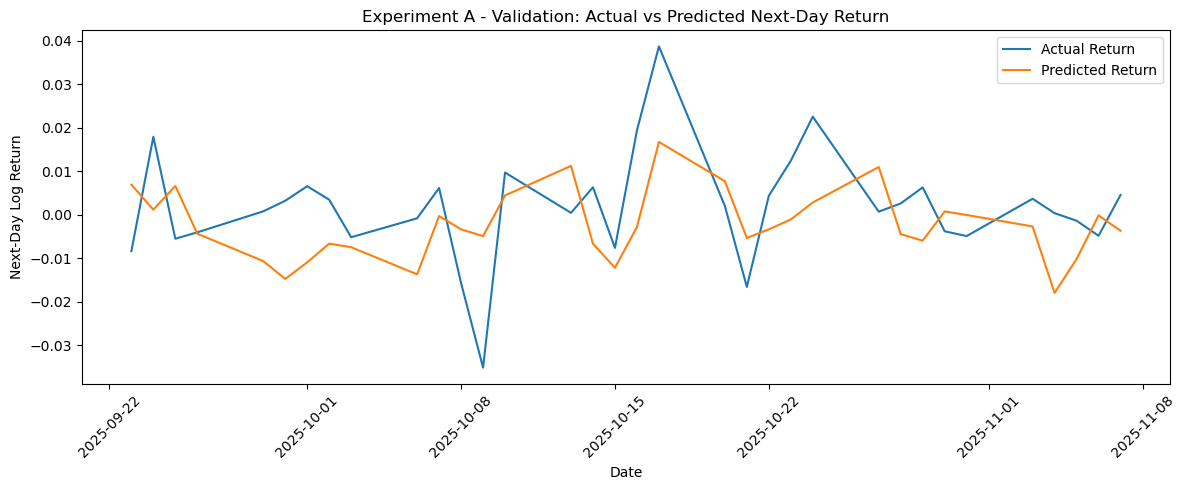

In [142]:
# Step 22: Plot Actual vs Predicted Return on Validation Set
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.plot(
    y_validation.index,
    y_validation.values,
    label="Actual Return"
)

plt.plot(
    y_validation.index,
    validation_pred_return,
    label="Predicted Return"
)

plt.title("Experiment A - Validation: Actual vs Predicted Next-Day Return")
plt.xlabel("Date")
plt.ylabel("Next-Day Log Return")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [146]:
# Step 23: Permutation importance on validation set

from sklearn.inspection import permutation_importance

importance_a = permutation_importance(
    model_a,
    X_validation,
    y_validation,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42
)

importance_frame_a = pd.DataFrame({
    "factor": aapl_factors,
    "importance": importance_a.importances_mean,
    "std": importance_a.importances_std
}).sort_values(
    "importance",
    ascending=False
)

display(importance_frame_a.round(6))

,factor,importance,std
4,close_to_ema_20,0.000347,0.000250
9,volume_z_20,0.000250,0.000351
7,realized_vol_20,0.000188,0.000212
1,log_return_5d,0.000162,0.000391
2,log_return_20d,-0.000179,0.000202
6,realized_vol_5,-0.000217,0.000495
5,rsi_14_scaled,-0.000250,0.000255
0,log_return_1d,-0.000388,0.000657
8,volume_change_1d,-0.000552,0.000598
3,close_to_ema_10,-0.000745,0.000375


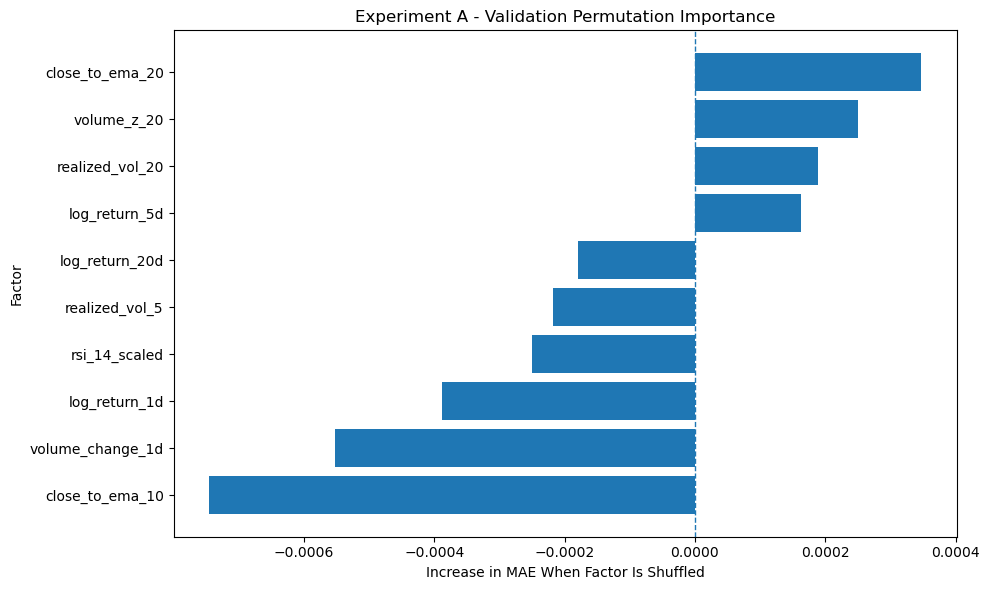

In [148]:
# Step 24: Plot Experiment A factor importance

plt.figure(figsize=(10, 6))

plt.barh(
    importance_frame_a["factor"],
    importance_frame_a["importance"]
)

plt.gca().invert_yaxis()

plt.title("Experiment A - Validation Permutation Importance")
plt.xlabel("Increase in MAE When Factor Is Shuffled")
plt.ylabel("Factor")

plt.axvline(x=0, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [152]:
def make_factors(data, prefix):
    x = data.sort_values("Date").copy()

    log_close = np.log(x["Close"])
    log_volume = np.log(x["Volume"])

    x[f"{prefix}_log_return_1d"] = log_close.diff(1)
    x[f"{prefix}_log_return_5d"] = log_close.diff(5)
    x[f"{prefix}_log_return_20d"] = log_close.diff(20)

    x[f"{prefix}_close_to_ema_10"] = x["Close"] / x["Close"].ewm(span=10, adjust=False).mean() - 1
    x[f"{prefix}_close_to_ema_20"] = x["Close"] / x["Close"].ewm(span=20, adjust=False).mean() - 1

    delta = x["Close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    rs = gain / loss
    x[f"{prefix}_rsi_14_scaled"] = (100 - 100 / (1 + rs)) / 100

    x[f"{prefix}_realized_vol_5"] = log_close.diff().rolling(5).std() * np.sqrt(252)
    x[f"{prefix}_realized_vol_20"] = log_close.diff().rolling(20).std() * np.sqrt(252)

    x[f"{prefix}_volume_change_1d"] = log_volume.diff()
    x[f"{prefix}_volume_z_20"] = (
        (log_volume - log_volume.rolling(20).mean())
        / log_volume.rolling(20).std()
    )

    return x

In [154]:
aapl_b = df[df["Ticker"] == "AAPL"].copy()
qqq_b = df[df["Ticker"] == "QQQ"].copy()

aapl_b = make_factors(aapl_b, "aapl")
qqq_b = make_factors(qqq_b, "qqq")

print(aapl_b.shape)
print(qqq_b.shape)

(0, 17)
(1255, 17)


In [156]:
print(df.shape)
print(df.columns.tolist())
print(df["Ticker"].value_counts())

(1255, 7)
['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Ticker
QQQ    1255
Name: count, dtype: int64


In [158]:
data_2025 = pd.read_csv(
    "data/processed/aligned_daily_ohlcv_2025_split.csv",
    parse_dates=["Date"]
)

print(data_2025.shape)
print(data_2025["Ticker"].value_counts())

(1000, 9)
Ticker
AAPL    250
MSFT    250
NVDA    250
QQQ     250
Name: count, dtype: int64


In [160]:
aapl_b = make_factors(
    data_2025[data_2025["Ticker"] == "AAPL"].copy(),
    "aapl"
)

qqq_b = make_factors(
    data_2025[data_2025["Ticker"] == "QQQ"].copy(),
    "qqq"
)

print(aapl_b.shape)
print(qqq_b.shape)

(250, 19)
(250, 19)


In [162]:
qqq_factors = [c for c in qqq_b.columns if c.startswith("qqq_")]

experiment_b = aapl_b.merge(
    qqq_b[["Date"] + qqq_factors],
    on="Date",
    how="inner"
)

# AAPL next-day return target
experiment_b["target_return"] = np.log(
    experiment_b["Close"].shift(-1) / experiment_b["Close"]
)

print(experiment_b.shape)
print(experiment_b[["Date", "Close", "target_return"]].head())

(250, 30)
        Date       Close  target_return
0 2025-01-02  242.093155      -0.002011
1 2025-01-03  241.606674       0.006716
2 2025-01-06  243.234848      -0.011453
3 2025-01-07  240.464951       0.002021
4 2025-01-08  240.951416      -0.024399


In [164]:
b_factors = (
    [c for c in aapl_b.columns if c.startswith("aapl_")]
    + qqq_factors
)

experiment_b_clean = experiment_b[
    ["Date", "Close"] + b_factors + ["target_return"]
].dropna().copy()

n = len(experiment_b_clean)
train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_b = experiment_b_clean.iloc[:train_end]
validation_b = experiment_b_clean.iloc[train_end:validation_end]
test_b = experiment_b_clean.iloc[validation_end:]

print("Total:", n)
print("Train:", len(train_b))
print("Validation:", len(validation_b))
print("Test:", len(test_b))
print("Number of factors:", len(b_factors))

Total: 229
Train: 160
Validation: 34
Test: 35
Number of factors: 20


In [166]:
from sklearn.base import clone

X_train_b = train_b[b_factors]
y_train_b = train_b["target_return"]

X_validation_b = validation_b[b_factors]
y_validation_b = validation_b["target_return"]

X_test_b = test_b[b_factors]
y_test_b = test_b["target_return"]

model_b = clone(model_a)
model_b.fit(X_train_b, y_train_b)

validation_pred_b = model_b.predict(X_validation_b)

print("Experiment B training completed.")

Experiment B training completed.


In [168]:
mae_b = mean_absolute_error(y_validation_b, validation_pred_b)
rmse_b = np.sqrt(mean_squared_error(y_validation_b, validation_pred_b))
r2_b = r2_score(y_validation_b, validation_pred_b)

direction_b = (
    np.sign(y_validation_b.values) == np.sign(validation_pred_b)
).mean()

spearman_b = pd.Series(
    validation_pred_b,
    index=y_validation_b.index
).corr(y_validation_b, method="spearman")

print(f"MAE                  : {mae_b:.6f}")
print(f"RMSE                 : {rmse_b:.6f}")
print(f"R²                   : {r2_b:.4f}")
print(f"Directional Accuracy : {direction_b:.2%}")
print(f"Spearman IC           : {spearman_b:.4f}")

MAE                  : 0.010094
RMSE                 : 0.013530
R²                   : -0.2163
Directional Accuracy : 61.76%
Spearman IC           : 0.2764


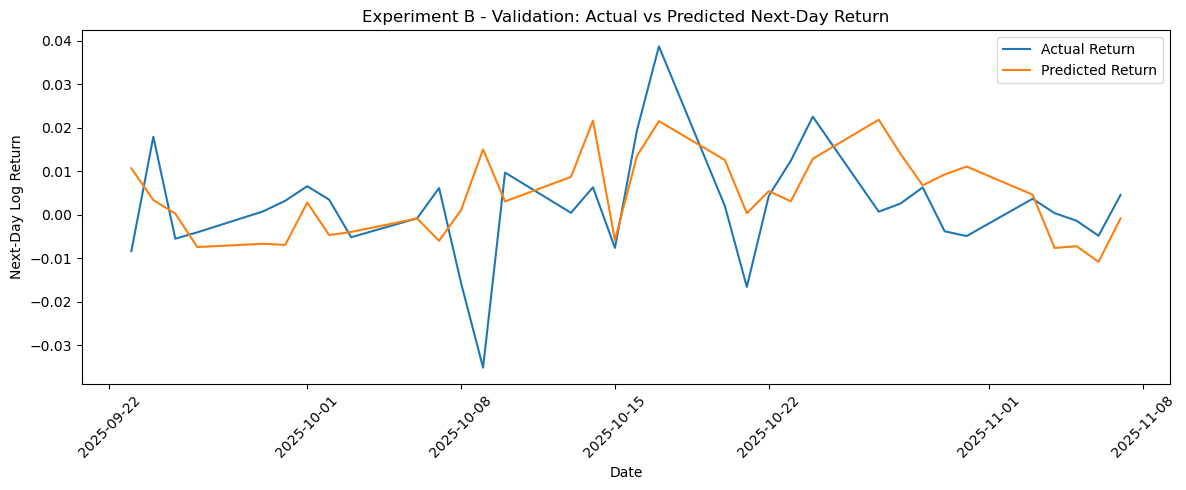

In [170]:
plt.figure(figsize=(12, 5))

plt.plot(
    validation_b["Date"],
    y_validation_b.values,
    label="Actual Return"
)

plt.plot(
    validation_b["Date"],
    validation_pred_b,
    label="Predicted Return"
)

plt.title("Experiment B - Validation: Actual vs Predicted Next-Day Return")
plt.xlabel("Date")
plt.ylabel("Next-Day Log Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

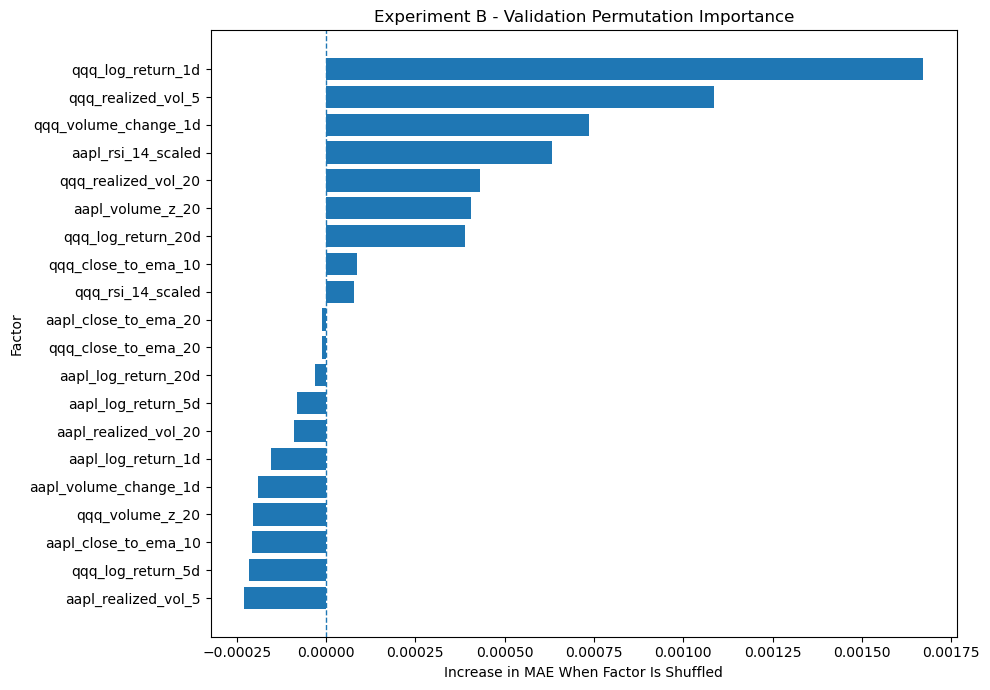

In [172]:
importance_b = permutation_importance(
    model_b,
    X_validation_b,
    y_validation_b,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42
)

importance_frame_b = pd.DataFrame({
    "factor": b_factors,
    "importance": importance_b.importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(
    importance_frame_b["factor"],
    importance_frame_b["importance"]
)

plt.gca().invert_yaxis()
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Experiment B - Validation Permutation Importance")
plt.xlabel("Increase in MAE When Factor Is Shuffled")
plt.ylabel("Factor")
plt.tight_layout()
plt.show()

In [174]:
msft_c = make_factors(
    data_2025[data_2025["Ticker"] == "MSFT"].copy(),
    "msft"
)

nvda_c = make_factors(
    data_2025[data_2025["Ticker"] == "NVDA"].copy(),
    "nvda"
)

print(msft_c.shape)
print(nvda_c.shape)

(250, 19)
(250, 19)


In [176]:
msft_factors = [c for c in msft_c.columns if c.startswith("msft_")]
nvda_factors = [c for c in nvda_c.columns if c.startswith("nvda_")]

experiment_c = (
    experiment_b
    .merge(msft_c[["Date"] + msft_factors], on="Date", how="inner")
    .merge(nvda_c[["Date"] + nvda_factors], on="Date", how="inner")
)

c_factors = b_factors + msft_factors + nvda_factors

print("Shape:", experiment_c.shape)
print("Number of factors:", len(c_factors))

Shape: (250, 50)
Number of factors: 40


In [178]:
experiment_c_clean = experiment_c[
    ["Date", "Close"] + c_factors + ["target_return"]
].dropna().copy()

n = len(experiment_c_clean)
train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_c = experiment_c_clean.iloc[:train_end]
validation_c = experiment_c_clean.iloc[train_end:validation_end]
test_c = experiment_c_clean.iloc[validation_end:]

print("Total:", n)
print("Train:", len(train_c))
print("Validation:", len(validation_c))
print("Test:", len(test_c))
print("Number of factors:", len(c_factors))

Total: 229
Train: 160
Validation: 34
Test: 35
Number of factors: 40


In [180]:
X_train_c = train_c[c_factors]
y_train_c = train_c["target_return"]

X_validation_c = validation_c[c_factors]
y_validation_c = validation_c["target_return"]

X_test_c = test_c[c_factors]
y_test_c = test_c["target_return"]

model_c = clone(model_a)
model_c.fit(X_train_c, y_train_c)

validation_pred_c = model_c.predict(X_validation_c)

print("Experiment C training completed.")

Experiment C training completed.


In [182]:
mae_c = mean_absolute_error(y_validation_c, validation_pred_c)
rmse_c = np.sqrt(mean_squared_error(y_validation_c, validation_pred_c))
r2_c = r2_score(y_validation_c, validation_pred_c)

direction_c = (
    np.sign(y_validation_c.values) == np.sign(validation_pred_c)
).mean()

spearman_c = pd.Series(
    validation_pred_c,
    index=y_validation_c.index
).corr(y_validation_c, method="spearman")

print(f"MAE                  : {mae_c:.6f}")
print(f"RMSE                 : {rmse_c:.6f}")
print(f"R²                   : {r2_c:.4f}")
print(f"Directional Accuracy : {direction_c:.2%}")
print(f"Spearman IC           : {spearman_c:.4f}")

MAE                  : 0.010320
RMSE                 : 0.013129
R²                   : -0.1453
Directional Accuracy : 67.65%
Spearman IC           : 0.2739


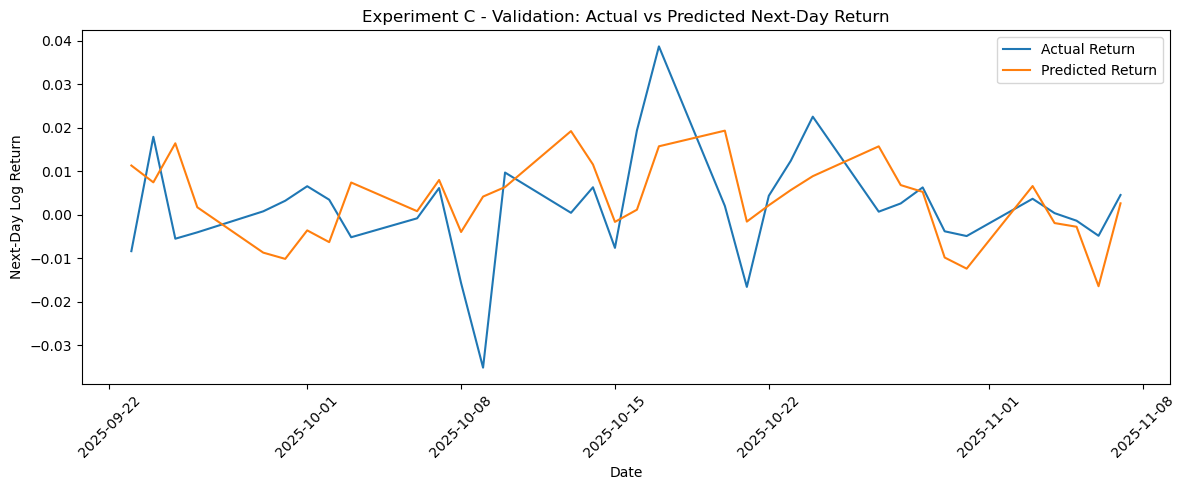

In [184]:
plt.figure(figsize=(12, 5))

plt.plot(
    validation_c["Date"],
    y_validation_c.values,
    label="Actual Return"
)

plt.plot(
    validation_c["Date"],
    validation_pred_c,
    label="Predicted Return"
)

plt.title("Experiment C - Validation: Actual vs Predicted Next-Day Return")
plt.xlabel("Date")
plt.ylabel("Next-Day Log Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

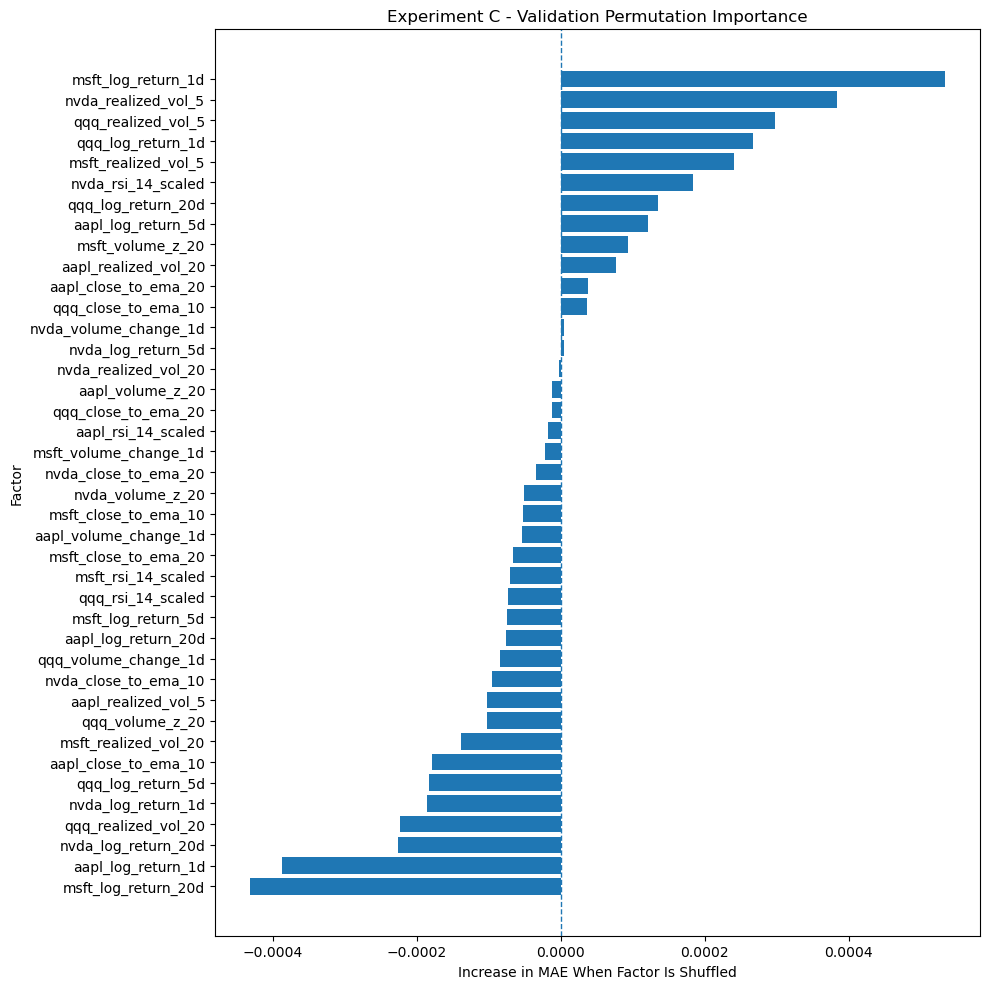

In [186]:
importance_c = permutation_importance(
    model_c,
    X_validation_c,
    y_validation_c,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42
)

importance_frame_c = pd.DataFrame({
    "factor": c_factors,
    "importance": importance_c.importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 10))
plt.barh(
    importance_frame_c["factor"],
    importance_frame_c["importance"]
)

plt.gca().invert_yaxis()
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Experiment C - Validation Permutation Importance")
plt.xlabel("Increase in MAE When Factor Is Shuffled")
plt.ylabel("Factor")
plt.tight_layout()
plt.show()

In [188]:
comparison = pd.DataFrame({
    "Experiment": ["A: AAPL", "B: AAPL + QQQ", "C: AAPL + QQQ + MSFT + NVDA"],
    "Factors": [10, 20, 40],
    "MAE": [0.011370, mae_b, mae_c],
    "RMSE": [0.013050, rmse_b, rmse_c],
    "R2": [-0.1315, r2_b, r2_c],
    "Directional_Accuracy": [0.5000, direction_b, direction_c],
    "Spearman_IC": [0.1618, spearman_b, spearman_c]
})

display(comparison.round(4))

,Experiment,Factors,MAE,RMSE,R2,Directional_Accuracy,Spearman_IC
0,A: AAPL,10,0.0114,0.0130,-0.1315,0.5000,0.1618
1,B: AAPL + QQQ,20,0.0101,0.0135,-0.2163,0.6176,0.2764
2,C: AAPL + QQQ + MSFT + NVDA,40,0.0103,0.0131,-0.1453,0.6765,0.2739


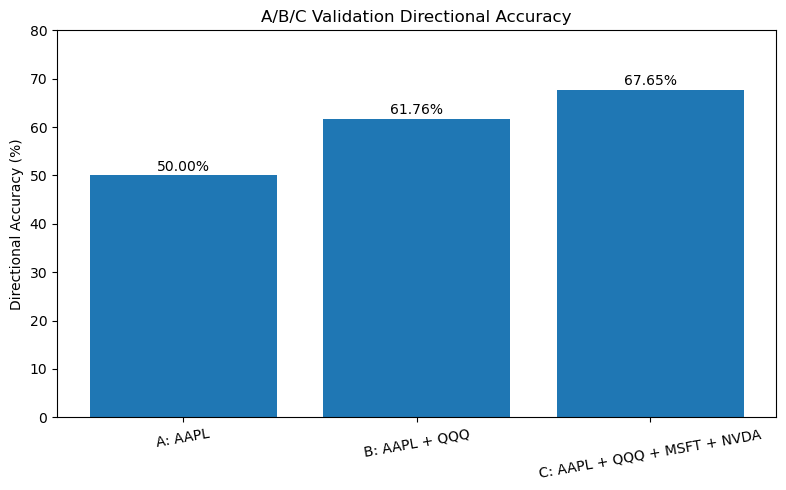

In [190]:
plt.figure(figsize=(8, 5))

labels = ["A: AAPL", "B: AAPL + QQQ", "C: AAPL + QQQ + MSFT + NVDA"]
accuracy = [50.00, direction_b * 100, direction_c * 100]

bars = plt.bar(labels, accuracy)

plt.ylabel("Directional Accuracy (%)")
plt.title("A/B/C Validation Directional Accuracy")
plt.ylim(0, 80)

for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [192]:
test_pred_a = model_a.predict(X_test)
test_pred_b = model_b.predict(X_test_b)
test_pred_c = model_c.predict(X_test_c)

print("Test predictions completed.")
print("A:", len(test_pred_a))
print("B:", len(test_pred_b))
print("C:", len(test_pred_c))

Test predictions completed.
A: 35
B: 35
C: 35


In [194]:
def evaluate_test(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Directional_Accuracy": (
            np.sign(y_true.values) == np.sign(y_pred)
        ).mean(),
        "Spearman_IC": pd.Series(y_pred).corr(
            pd.Series(y_true.values), method="spearman"
        )
    }

test_results = pd.DataFrame([
    {"Experiment": "A: AAPL", **evaluate_test(y_test, test_pred_a)},
    {"Experiment": "B: AAPL + QQQ", **evaluate_test(y_test_b, test_pred_b)},
    {"Experiment": "C: AAPL + QQQ + MSFT + NVDA", **evaluate_test(y_test_c, test_pred_c)}
])

display(test_results.round(4))

,Experiment,MAE,RMSE,R2,Directional_Accuracy,Spearman_IC
0,A: AAPL,0.0100,0.0122,-0.8623,0.4571,-0.0227
1,B: AAPL + QQQ,0.0089,0.0106,-0.3934,0.4857,0.0765
2,C: AAPL + QQQ + MSFT + NVDA,0.0105,0.0125,-0.9423,0.5429,0.3787


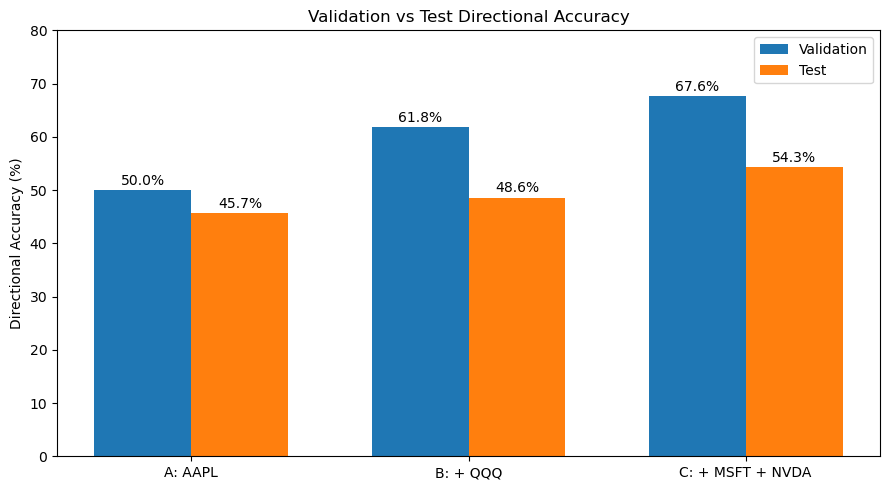

In [196]:
labels = ["A: AAPL", "B: + QQQ", "C: + MSFT + NVDA"]

validation_acc = [50.00, direction_b * 100, direction_c * 100]
test_acc = [
    test_results.loc[0, "Directional_Accuracy"] * 100,
    test_results.loc[1, "Directional_Accuracy"] * 100,
    test_results.loc[2, "Directional_Accuracy"] * 100
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 5))

bars1 = plt.bar(x - width/2, validation_acc, width, label="Validation")
bars2 = plt.bar(x + width/2, test_acc, width, label="Test")

plt.ylabel("Directional Accuracy (%)")
plt.title("Validation vs Test Directional Accuracy")
plt.xticks(x, labels)
plt.ylim(0, 80)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            value + 1,
            f"{value:.1f}%",
            ha="center"
        )

plt.tight_layout()
plt.show()